In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt

pd.options.display.max_rows = 10
pd.options.display.float_format = "{:.1f}".format


In [ ]:
training_df = pd.read_csv(filepath_or_buffer="https://download.mlcc.google.com/mledu-datasets/california_housing_train.csv")
training_df["median_house_value"] /= 1000.0

training_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.3,34.2,15.0,5612.0,1283.0,1015.0,472.0,1.5,66.9
1,-114.5,34.4,19.0,7650.0,1901.0,1129.0,463.0,1.8,80.1
2,-114.6,33.7,17.0,720.0,174.0,333.0,117.0,1.7,85.7
3,-114.6,33.6,14.0,1501.0,337.0,515.0,226.0,3.2,73.4
4,-114.6,33.6,20.0,1454.0,326.0,624.0,262.0,1.9,65.5


In [ ]:
training_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.0,17000.0,17000.0,17000.0,17000.0,17000.0,17000.0,17000.0,17000.0
mean,-119.6,35.6,28.6,2643.7,539.4,1429.6,501.2,3.9,207.3
std,2.0,2.1,12.6,2179.9,421.5,1147.9,384.5,1.9,116.0
min,-124.3,32.5,1.0,2.0,1.0,3.0,1.0,0.5,15.0
25%,-121.8,33.9,18.0,1462.0,297.0,790.0,282.0,2.6,119.4
50%,-118.5,34.2,29.0,2127.0,434.0,1167.0,409.0,3.5,180.4
75%,-118.0,37.7,37.0,3151.2,648.2,1721.0,605.2,4.8,265.0
max,-114.3,42.0,52.0,37937.0,6445.0,35682.0,6082.0,15.0,500.0


In [ ]:
def build_model(my_learning_rate):
  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Dense(units=1, input_shape=(1,)))
  model.compile(optimizer= tf.keras.optimizers.RMSprop(learning_rate=my_learning_rate),
                loss='mean_squared_error',
                metrics=[tf.keras.metrics.RootMeanSquaredError()])
  return model

def train_model(model, df, feature, label, epochs, batch_size):
  history = model.fit(x=df[feature],
                      y=df[label],
                      batch_size=batch_size,
                      epochs=epochs)

  trained_weight = model.get_weights()[0]
  trained_bias = model.get_weights()[1]

  epochs = history.epoch

  hist = pd.DataFrame(history.history)

  rmse = hist["root_mean_squared_error"]

  return trained_weight, trained_bias, epochs, rmse

In [ ]:
def plot_the_model(trained_weight, trained_bias, feature, label):

  plt.xlabel("feature")
  plt.ylabel("label")

  random_examples = training_df.sample(n=200)
  plt.scatter(random_examples[feature], random_examples[label])

  x0 = 0
  y0 = trained_bias
  x1 = random_examples[feature].max()
  y1 = trained_bias + (trained_weight * x1)
  plt.plot([x0, x1], [y0, y1], c='r')

  plt.show()

def plot_the_loss_curve(epochs, rmse):

  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Root Mean Squared Error')

  plt.plot(epochs, rmse, label="Loss")
  plt.legend()
  plt.ylim([rmse.min()*0.97, rmse.max()])
  plt.show()


Epoch 1/70
567/567 [==============================] - 2s 2ms/step - loss: 4124809.7500 - root_mean_squared_error: 2030.9628
Epoch 2/70
567/567 [==============================] - 1s 2ms/step - loss: 27939.3965 - root_mean_squared_error: 167.1508
Epoch 3/70
567/567 [==============================] - 1s 2ms/step - loss: 27141.7578 - root_mean_squared_error: 164.7476
Epoch 4/70
567/567 [==============================] - 1s 1ms/step - loss: 26375.4551 - root_mean_squared_error: 162.4052
Epoch 5/70
567/567 [==============================] - 1s 1ms/step - loss: 25509.9863 - root_mean_squared_error: 159.7185
Epoch 6/70
567/567 [==============================] - 1s 1ms/step - loss: 25075.0605 - root_mean_squared_error: 158.3511
Epoch 7/70
567/567 [==============================] - 1s 1ms/step - loss: 24034.1309 - root_mean_squared_error: 155.0294
Epoch 8/70
567/567 [==============================] - 1s 1ms/step - loss: 23487.8750 - root_mean_squared_error: 153.2575
Epoch 9/70
567/567 [=========

/usr/local/lib/python3.10/dist-packages/numpy/core/shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


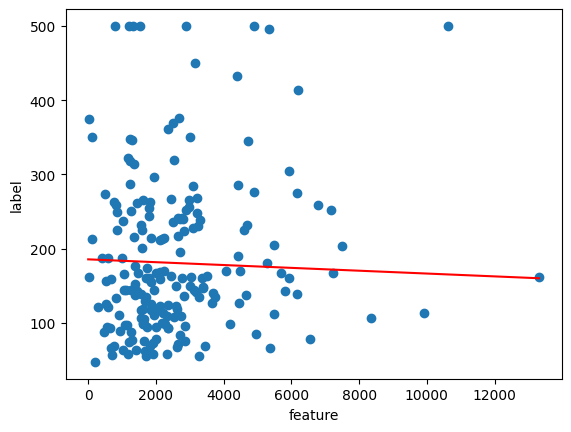

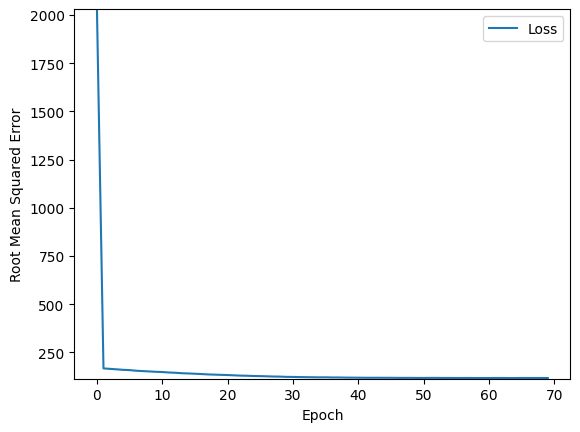

In [ ]:
learning_rate = 0.01
batch_size = 30
epochs = 70

my_feature = "total_rooms"
my_label = "median_house_value"

my_model = None

my_model = build_model(learning_rate)
weight, bias, epochs, rmse = train_model(my_model,training_df,
                                        my_feature, my_label,
                                        epochs, batch_size)

print("\nThe learned weight of ypur model is %.4f" %weight)
print("The learned bias of your model is %.4f" %bias)

plot_the_model(weight, bias, my_feature, my_label)
plot_the_loss_curve(epochs, rmse)


In [ ]:
def predict_house_values(n, feature, label):

  batch = training_df[feature][10000:10000 + n]
  predicted_values = my_model.predict_on_batch(x=batch)

  print("feature   label          predicted")
  print("  value   value          value")
  print("          in thousand$   in thousand$")
  print("--------------------------------------")


  for i in range(n):
    print ("%5.0f %6.0f %15.0f" % (training_df[feature][10000 + i],
                                   training_df[label][10000 + i],
                                   predicted_values[i][0] ))
  #return predicted_values

#def calculate_variance(my_label, predicted_values):
  #if isinstance(my_label, str):
        #my_label = training_df[my_label].values.astype(float)
  #my_label = my_label.astype(float)
  #variance = np.var(my_label - predicted_values)
  #variance_percentage = variance / np.mean(my_label) * 100
  #return variance_percentage

predict_house_values(10, my_feature, my_label)

#predicted_values = predict_house_values(10, my_feature, my_label)
#variance = calculate_variance(training_df[my_label].values, predicted_values)
#print("The Variance between the actual and predicted values is :%.2f%%" %variance)





feature   label          predicted
  value   value          value
          in thousand$   in thousand$
--------------------------------------
 1960     53             182
 3400     92             179
 3677     69             179
 2202     62             181
 2403     80             181
 5652    295             175
 3318    500             179
 2552    342             181
 1364    118             183
 3468    128             179


Epoch 1/18
5667/5667 [==============================] - 10s 2ms/step - loss: 29244.2031 - root_mean_squared_error: 171.0094
Epoch 2/18
5667/5667 [==============================] - 8s 1ms/step - loss: 20128.9980 - root_mean_squared_error: 141.8767
Epoch 3/18
5667/5667 [==============================] - 9s 2ms/step - loss: 18321.6543 - root_mean_squared_error: 135.3575
Epoch 4/18
5667/5667 [==============================] - 9s 2ms/step - loss: 18620.6914 - root_mean_squared_error: 136.4577
Epoch 5/18
5667/5667 [==============================] - 8s 1ms/step - loss: 18429.5586 - root_mean_squared_error: 135.7555
Epoch 6/18
5667/5667 [==============================] - 9s 2ms/step - loss: 18427.0078 - root_mean_squared_error: 135.7461
Epoch 7/18
5667/5667 [==============================] - 9s 2ms/step - loss: 18037.7344 - root_mean_squared_error: 134.3046
Epoch 8/18
5667/5667 [==============================] - 8s 1ms/step - loss: 17986.3789 - root_mean_squared_error: 134.1133
Epoch 9/18
5667

/usr/local/lib/python3.10/dist-packages/numpy/core/shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


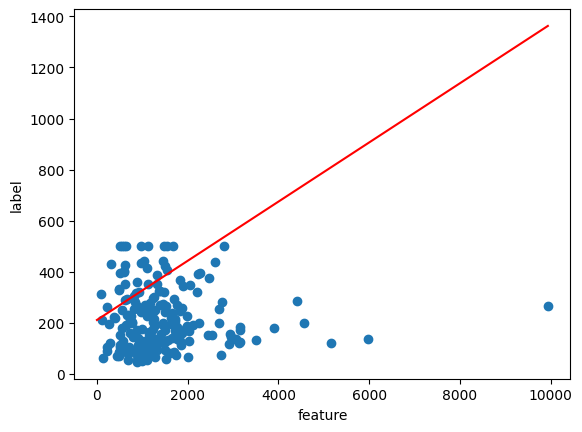

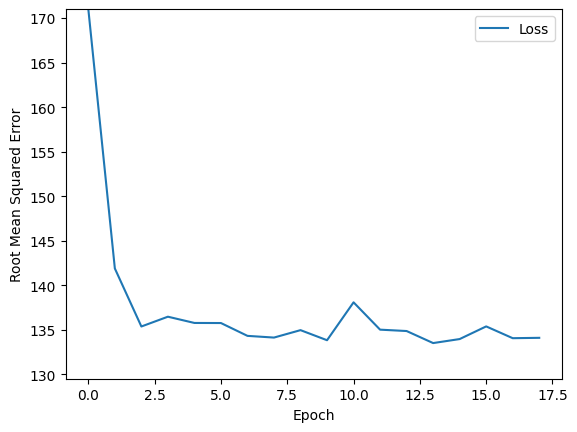

In [ ]:
my_feature = "population"

learning_rate = 0.05
epochs = 18
batch_size = 3



my_model = build_model(learning_rate)
weight, bias, epochs, rmse = train_model(my_model, training_df,
                                         my_feature, my_label,
                                         epochs, batch_size)

print("\nThe learned weight of your model is %.4f" %weight)
print("The learned bias of your model is %.4f" %bias)

plot_the_model(weight, bias, my_feature, my_label)
plot_the_loss_curve(epochs, rmse)

In [ ]:
predict_house_values(10, my_feature, my_label)

feature   label          predicted
  value   value          value
          in thousand$   in thousand$
--------------------------------------
 1286     53             360
 1867     92             427
 2191     69             465
 1052     62             333
 1647     80             402
 2312    295             479
 1604    500             397
 1066    342             335
  338    118             250
 1604    128             397


Epoch 1/20
3400/3400 [==============================] - 5s 1ms/step - loss: 39014.8867 - root_mean_squared_error: 197.5219
Epoch 2/20
3400/3400 [==============================] - 5s 2ms/step - loss: 20075.8906 - root_mean_squared_error: 141.6894
Epoch 3/20
3400/3400 [==============================] - 4s 1ms/step - loss: 15298.1553 - root_mean_squared_error: 123.6857
Epoch 4/20
3400/3400 [==============================] - 5s 1ms/step - loss: 15264.4834 - root_mean_squared_error: 123.5495
Epoch 5/20
3400/3400 [==============================] - 5s 1ms/step - loss: 15399.7686 - root_mean_squared_error: 124.0958
Epoch 6/20
3400/3400 [==============================] - 4s 1ms/step - loss: 15375.0000 - root_mean_squared_error: 123.9960
Epoch 7/20
3400/3400 [==============================] - 5s 2ms/step - loss: 15417.5176 - root_mean_squared_error: 124.1673
Epoch 8/20
3400/3400 [==============================] - 5s 1ms/step - loss: 15403.5225 - root_mean_squared_error: 124.1109
Epoch 9/20
3400/

/usr/local/lib/python3.10/dist-packages/numpy/core/shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


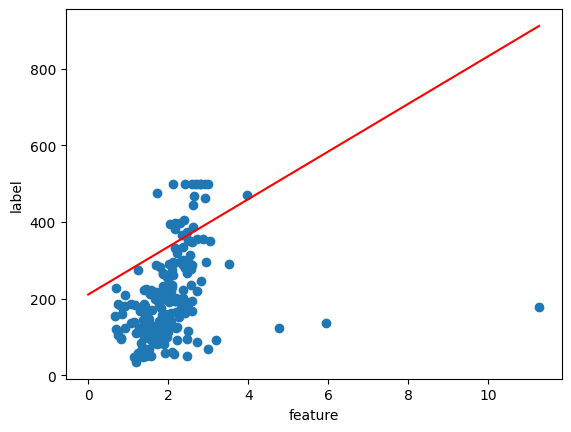

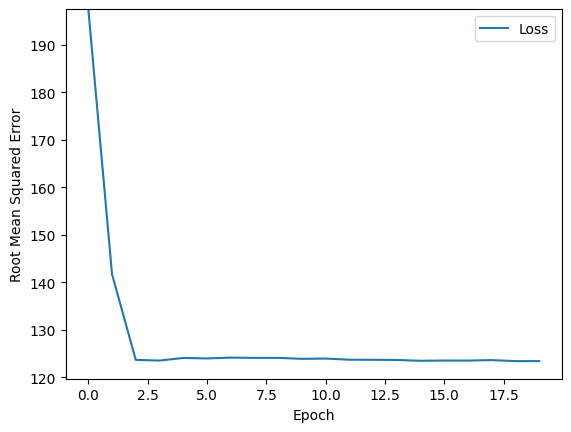

feature   label          predicted
  value   value          value
          in thousand$   in thousand$
--------------------------------------
    2     53             180
    2     92             198
    2     69             189
    2     62             215
    1     80             176
    2    295             237
    2    500             214
    2    342             234
    4    118             336
    2    128             219


In [ ]:
training_df['room_per_person'] = training_df['total_rooms'] / training_df['population']

my_feature = 'room_per_person'

learning_rate = 0.01
epochs = 20
batch_size = 5


my_model = build_model(learning_rate)
weight, bais, epochs, rmse = train_model(my_model, training_df,
                                         my_feature, my_label,
                                         epochs, batch_size)

print("\nThe learned weight of the model is %.4f" %weight)
print("\nThe learned bias of the model is %.4f" %bias)

plot_the_model(weight, bias, my_feature, my_label)
plot_the_loss_curve(epochs, rmse)

predict_house_values(10, my_feature, my_label)


In [ ]:
training_df.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,room_per_person
longitude,1.0,-0.9,-0.1,0.0,0.1,0.1,0.1,-0.0,-0.0,-0.1
latitude,-0.9,1.0,0.0,-0.0,-0.1,-0.1,-0.1,-0.1,-0.1,0.1
housing_median_age,-0.1,0.0,1.0,-0.4,-0.3,-0.3,-0.3,-0.1,0.1,-0.1
total_rooms,0.0,-0.0,-0.4,1.0,0.9,0.9,0.9,0.2,0.1,0.1
total_bedrooms,0.1,-0.1,-0.3,0.9,1.0,0.9,1.0,-0.0,0.0,0.0
population,0.1,-0.1,-0.3,0.9,0.9,1.0,0.9,-0.0,-0.0,-0.1
households,0.1,-0.1,-0.3,0.9,1.0,0.9,1.0,0.0,0.1,-0.0
median_income,-0.0,-0.1,-0.1,0.2,-0.0,-0.0,0.0,1.0,0.7,0.2
median_house_value,-0.0,-0.1,0.1,0.1,0.0,-0.0,0.1,0.7,1.0,0.2
room_per_person,-0.1,0.1,-0.1,0.1,0.0,-0.1,-0.0,0.2,0.2,1.0


Epoch 1/20
266/266 [==============================] - 1s 1ms/step - loss: 32864.1445 - root_mean_squared_error: 181.2847
Epoch 2/20
266/266 [==============================] - 0s 1ms/step - loss: 8921.0518 - root_mean_squared_error: 94.4513
Epoch 3/20
266/266 [==============================] - 0s 1ms/step - loss: 7017.1250 - root_mean_squared_error: 83.7683
Epoch 4/20
266/266 [==============================] - 0s 1ms/step - loss: 7016.1392 - root_mean_squared_error: 83.7624
Epoch 5/20
266/266 [==============================] - 0s 1ms/step - loss: 7016.8882 - root_mean_squared_error: 83.7669
Epoch 6/20
266/266 [==============================] - 0s 2ms/step - loss: 7015.5811 - root_mean_squared_error: 83.7591
Epoch 7/20
266/266 [==============================] - 0s 2ms/step - loss: 7017.0215 - root_mean_squared_error: 83.7677
Epoch 8/20
266/266 [==============================] - 0s 1ms/step - loss: 7015.0347 - root_mean_squared_error: 83.7558
Epoch 9/20
266/266 [==========================

/usr/local/lib/python3.10/dist-packages/numpy/core/shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


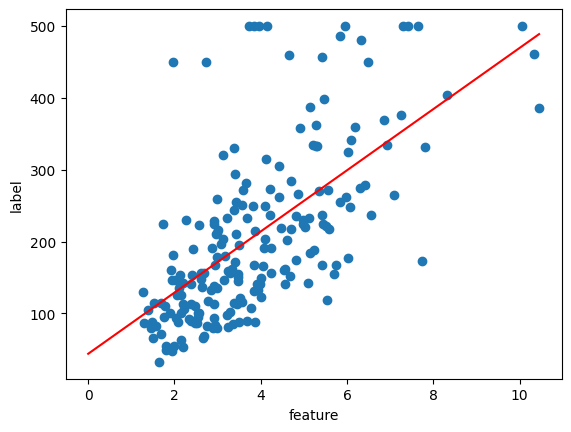

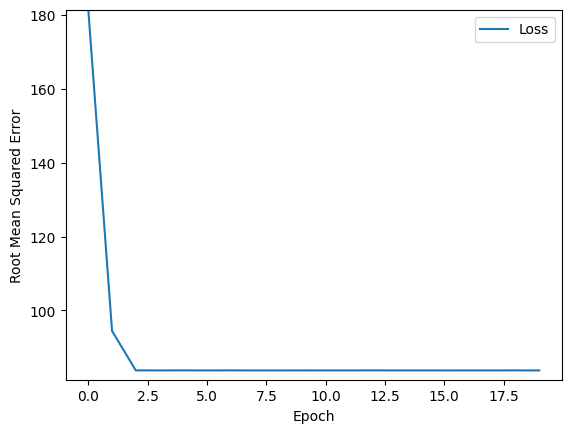

feature   label          predicted
  value   value          value
          in thousand$   in thousand$
--------------------------------------
    2     53             135
    4     92             214
    3     69             155
    2     62             133
    3     80             155
    2    295             149
   10    500             460
    5    342             262
    2    118             148
    4    128             223


In [ ]:
my_feature = 'median_income'

learning_rate = 0.1
epochs = 20
batch_size = 64

my_model = build_model(learning_rate)
weight, bias, epochs, rmse = train_model(my_model, training_df,
                                         my_feature, my_label,
                                         epochs, batch_size)

plot_the_model(weight, bias, my_feature,  my_label)
plot_the_loss_curve(epochs, rmse)

predict_house_values(10, my_feature, my_label)

Epoch 1/30
3400/3400 [==============================] - 5s 1ms/step - loss: 19116.5586 - root_mean_squared_error: 138.2626
Epoch 2/30
3400/3400 [==============================] - 4s 1ms/step - loss: 13997.8779 - root_mean_squared_error: 118.3126
Epoch 3/30
3400/3400 [==============================] - 5s 2ms/step - loss: 13996.5352 - root_mean_squared_error: 118.3070
Epoch 4/30
3400/3400 [==============================] - 4s 1ms/step - loss: 13994.7959 - root_mean_squared_error: 118.2996
Epoch 5/30
3400/3400 [==============================] - 4s 1ms/step - loss: 13995.2725 - root_mean_squared_error: 118.3016
Epoch 6/30
3400/3400 [==============================] - 5s 2ms/step - loss: 13985.6904 - root_mean_squared_error: 118.2611
Epoch 7/30
3400/3400 [==============================] - 4s 1ms/step - loss: 13984.5352 - root_mean_squared_error: 118.2562
Epoch 8/30
3400/3400 [==============================] - 5s 1ms/step - loss: 13985.3262 - root_mean_squared_error: 118.2596
Epoch 9/30
3400/

/usr/local/lib/python3.10/dist-packages/numpy/core/shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


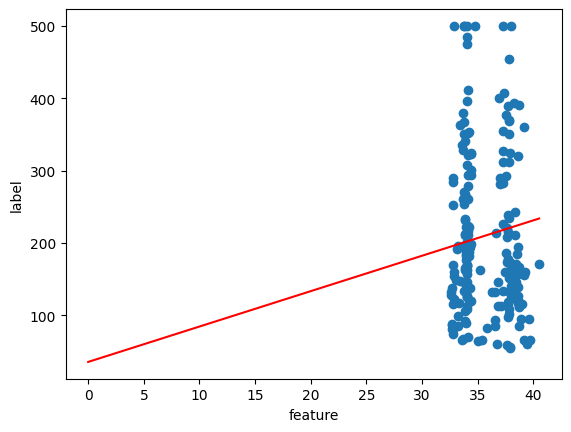

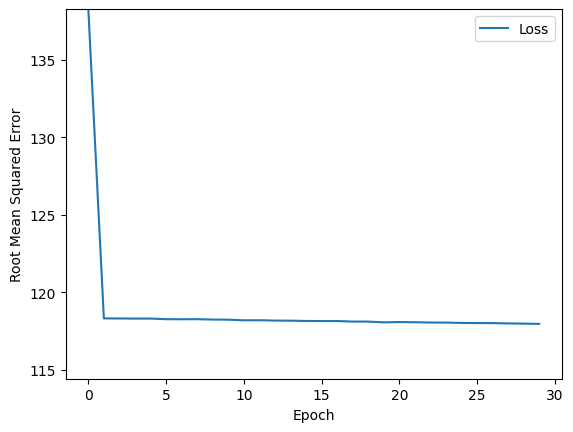

feature   label          predicted
  value   value          value
          in thousand$   in thousand$
--------------------------------------
   37     53             215
   36     92             213
   36     69             213
   36     62             213
   36     80             210
   34    295             204
   34    500             204
   34    342             204
   39    118             225
   37    128             216


In [ ]:
my_feature = 'latitude'

learning_rate = 0.01
epochs = 30
batch_size = 5

my_model = build_model(learning_rate)
weight, bias, epochs, rmse = train_model(my_model, training_df,
                                         my_feature, my_label,
                                         epochs, batch_size)

plot_the_model(weight, bias, my_feature, my_label)
plot_the_loss_curve(epochs, rmse)

predict_house_values(10, my_feature, my_label)